<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 22: Frequency-Domain Time Series Analysis, Filtering, and Spectral Analysis

**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences  

This notebook demonstrates the foundational concepts of transitioning data from the time domain to the frequency domain. Frequency domain analysis is based on the idea that any stationary time series can be decomposed into a sum of sine and cosine waves of different frequencies. The time domain expresses a data point as a function of its own lagged values and errors, whereas the frequency domain expresses it as a combination of periodic oscillations.

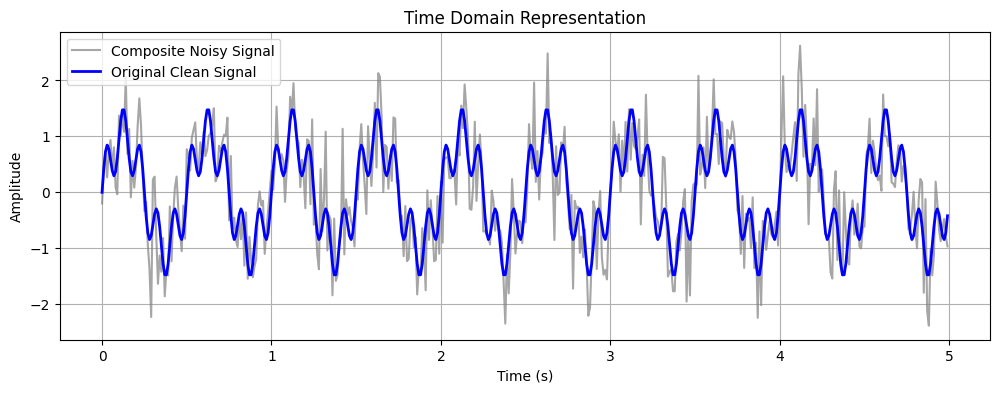

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import welch, butter, filtfilt
from statsmodels.graphics.tsaplots import plot_acf

fs = 100
t = np.arange(0, 5, 1/fs)

freq1 = 2
freq2 = 10
signal = np.sin(2 * np.pi * freq1 * t) + 0.5 * np.sin(2 * np.pi * freq2 * t)
noise = np.random.normal(0, 0.5, len(t))
noisy_signal = signal + noise

plt.figure(figsize=(12, 4))
plt.plot(t, noisy_signal, label="Composite Noisy Signal", color='gray', alpha=0.7)
plt.plot(t, signal, label="Original Clean Signal", color='blue', linewidth=2)
plt.title("Time Domain Representation")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

## 1. Exploring Frequency Content in the Time Domain

Before converting to the frequency domain entirely, we can estimate frequency content using time-domain techniques:

* **Zero-Crossing Rate (ZCR)**: The simplest time-domain proxy for frequency. It is a count of how many times the signal's value crosses the zero axis within a specific time frame.
* **Autocorrelation Function (ACF)**: Measures how well a signal matches a shifted version of itself. If a signal has a strong periodic component, the ACF will show distinct peaks at lags corresponding to that period.

Total zero crossings for the 5-second clean signal: 20


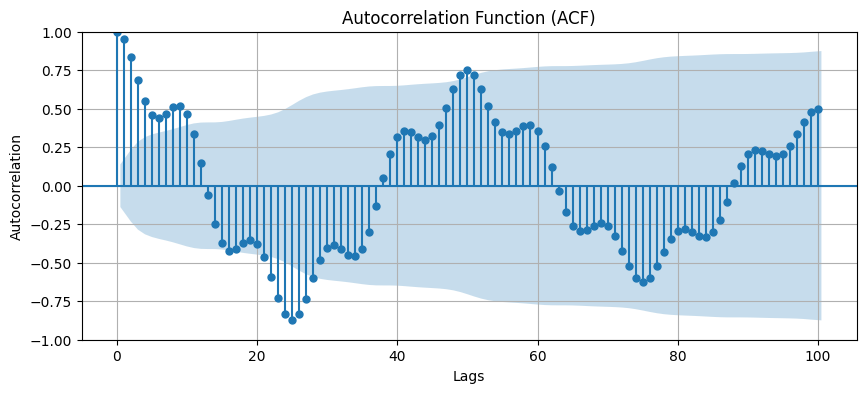

In [2]:
zero_crossings = np.where(np.diff(np.sign(signal)))[0]
print(f"Total zero crossings for the 5-second clean signal: {len(zero_crossings)}")

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(signal[:200], lags=100, ax=ax)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.grid()
plt.show()

## 2. The Fourier Transform

To move from time to frequency, we use the Fourier Transform. It takes a function as the input and outputs another function that describes the frequency content. For discrete data, we use the Discrete Fourier Transform (DFT) and the Fast Fourier Transform (FFT).

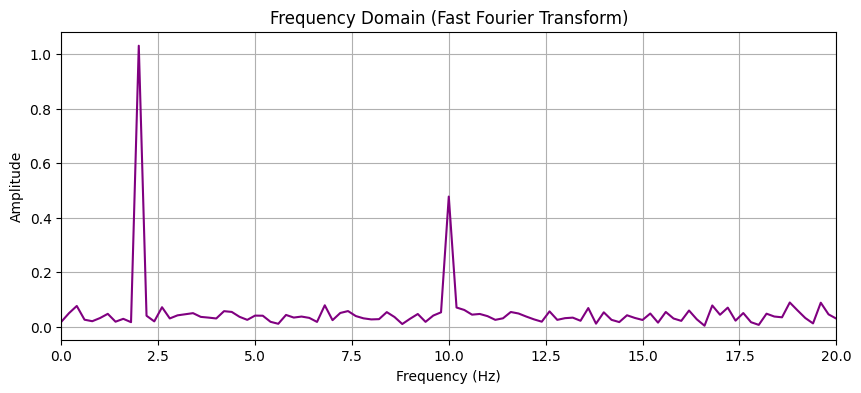

In [3]:
N = len(t)
yf = fft(noisy_signal)
xf = fftfreq(N, 1/fs)[:N//2]

plt.figure(figsize=(10, 4))
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]), color='purple')
plt.title("Frequency Domain (Fast Fourier Transform)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0, 20)
plt.grid()
plt.show()

## 3. Power Spectral Density (PSD)

Power Spectral Density (PSD) is a measure of how the power of a signal is distributed across different frequencies. The units of a PSD are the units of the signal squared divided by Hz.

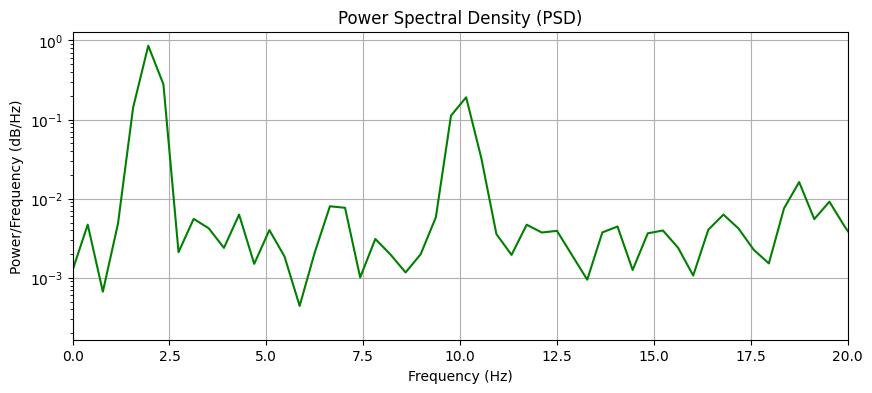

In [4]:
frequencies, psd = welch(noisy_signal, fs, nperseg=256)

plt.figure(figsize=(10, 4))
plt.semilogy(frequencies, psd, color='green')
plt.title("Power Spectral Density (PSD)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.xlim(0, 20)
plt.grid()
plt.show()

## 4. Waveform Filtering

Waveform filtering is the process of altering a signal by keeping desired frequencies and discarding others. We will apply a **Low-Pass Filter (LPF)**, which allows frequencies below a specific cutoff frequency to pass through unhindered, while attenuating frequencies above it.

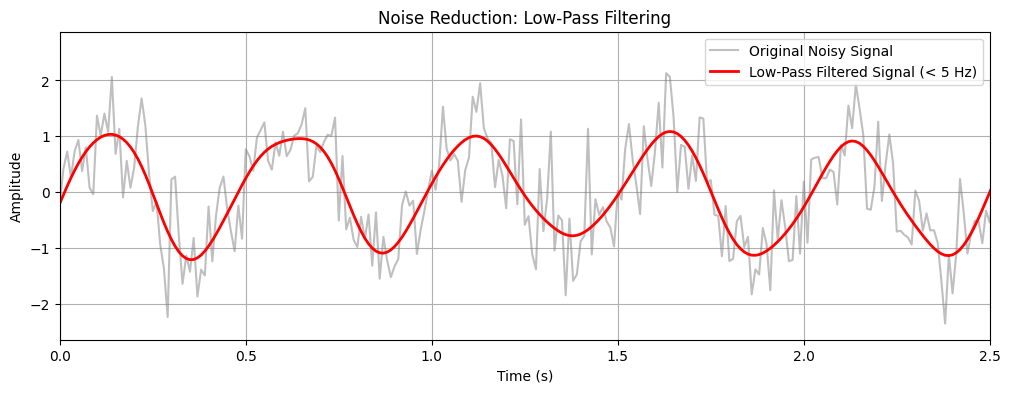

In [5]:
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

cutoff_frequency = 5.0
filtered_signal = butter_lowpass_filter(noisy_signal, cutoff_frequency, fs)

plt.figure(figsize=(12, 4))
plt.plot(t, noisy_signal, label="Original Noisy Signal", color='gray', alpha=0.5)
plt.plot(t, filtered_signal, label="Low-Pass Filtered Signal (< 5 Hz)", color='red', linewidth=2)
plt.title("Noise Reduction: Low-Pass Filtering")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 2.5)
plt.legend()
plt.grid()
plt.show()

## 5. High-Pass Filtering

A **High-Pass Filter (HPF)** does the exact opposite of a low-pass filter. It allows frequencies *above* a certain cutoff threshold to pass through while attenuating the lower frequencies. In our composite signal, applying a high-pass filter with a cutoff of 5 Hz will remove the slow, rolling 2 Hz wave, leaving behind only the faster 10 Hz oscillations and the high-frequency random noise.

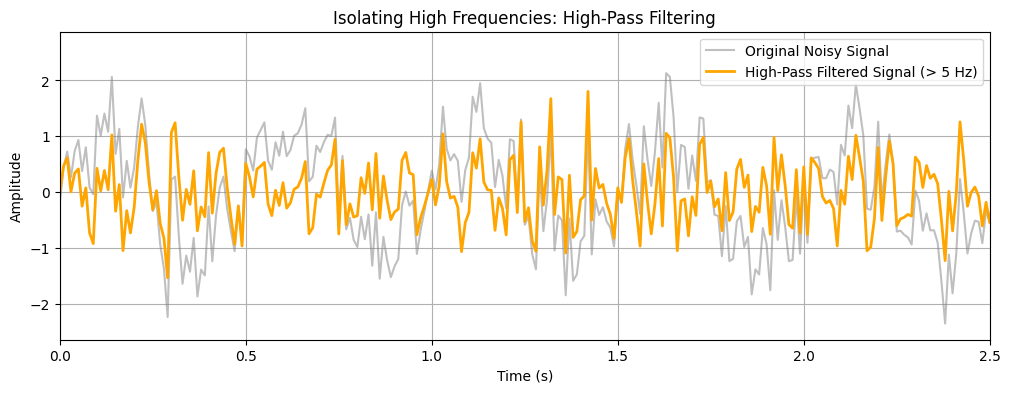

In [6]:
# Design a Butterworth High-Pass Filter
def butter_highpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    y = filtfilt(b, a, data)
    return y

# Apply the filter with a 5 Hz cutoff to remove the low-frequency 2 Hz component
cutoff_high = 5.0
high_filtered_signal = butter_highpass_filter(noisy_signal, cutoff_high, fs)

plt.figure(figsize=(12, 4))
plt.plot(t, noisy_signal, label="Original Noisy Signal", color='gray', alpha=0.5)
plt.plot(t, high_filtered_signal, label="High-Pass Filtered Signal (> 5 Hz)", color='orange', linewidth=2)
plt.title("Isolating High Frequencies: High-Pass Filtering")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 2.5)
plt.legend()
plt.grid()
plt.show()

## 6. Band-Pass Filtering

A **Band-Pass Filter (BPF)** is highly targeted. It combines the principles of both low-pass and high-pass filters to allow only a specific "band" (or range) of frequencies to pass through, effectively blocking everything above and below that range.

If we want to surgically extract *only* the 10 Hz component from our original noisy signal (stripping away both the 2 Hz wave and the random high-frequency noise), we can set a passband tightly around 10 Hz (e.g., 8 Hz to 12 Hz).

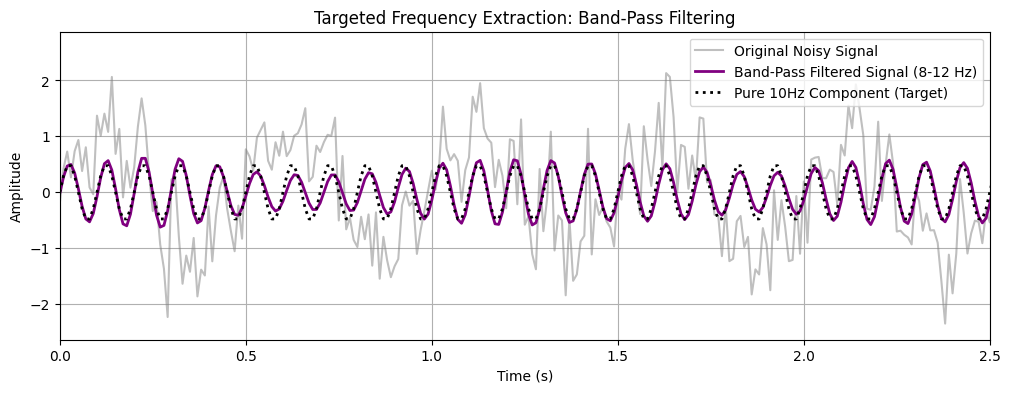

In [7]:
# Design a Butterworth Band-Pass Filter
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band', analog=False)
    y = filtfilt(b, a, data)
    return y

# Apply the filter to isolate the 10 Hz signal (passband: 8 Hz to 12 Hz)
low_cutoff = 8.0
high_cutoff = 12.0
band_filtered_signal = butter_bandpass_filter(noisy_signal, low_cutoff, high_cutoff, fs)

plt.figure(figsize=(12, 4))
plt.plot(t, noisy_signal, label="Original Noisy Signal", color='gray', alpha=0.5)
plt.plot(t, band_filtered_signal, label="Band-Pass Filtered Signal (8-12 Hz)", color='purple', linewidth=2)
# Also plot the pure 10 Hz mathematical component to show how well the filter worked
pure_10Hz = 0.5 * np.sin(2 * np.pi * 10 * t)
plt.plot(t, pure_10Hz, label="Pure 10Hz Component (Target)", color='black', linestyle=':', linewidth=2)

plt.title("Targeted Frequency Extraction: Band-Pass Filtering")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 2.5)
plt.legend()
plt.grid()
plt.show()

## 7. Band-Stop (Notch) Filtering

A **Band-Stop Filter** (often called a **Notch Filter** when the rejected band is very narrow) does the opposite of a band-pass filter. It completely blocks a very specific, narrow band of frequencies, allowing everything above and below that band to pass through unaltered.

**Real-World Application:** When geophysicists use Ground Penetrating Radar (GPR) or electrical resistivity to map groundwater, sensitive antennas easily pick up the alternating current (AC) hum radiating from overhead power lines. In the United States, this hum operates at exactly 60 Hz. A 60 Hz band-stop filter is routinely applied to the raw data to specifically remove the power line hum while keeping the broad spectrum of the actual geological data perfectly intact.

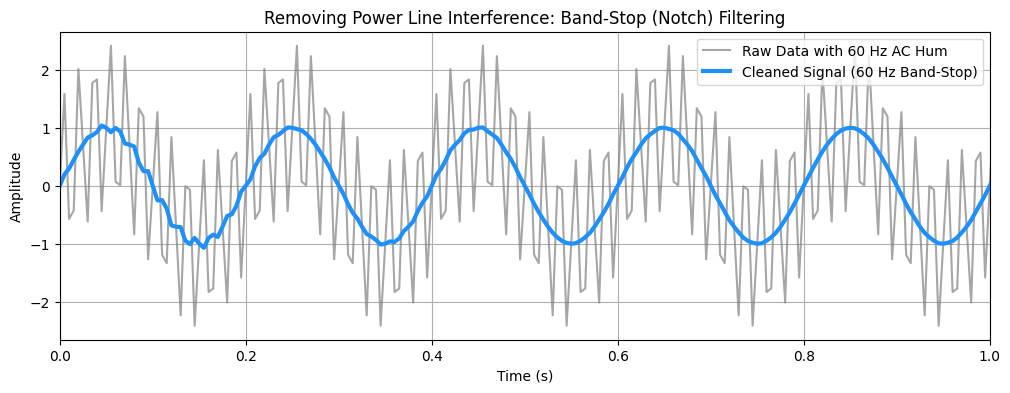

In [8]:
# We need a higher sampling rate for this example to accurately capture 60 Hz
# (The Nyquist frequency must be at least 120 Hz)
fs_high = 200
t_high = np.arange(0, 2, 1/fs_high)

# Simulate a clean geological signal (e.g., 5 Hz) contaminated by massive 60 Hz AC power line noise
geo_signal = np.sin(2 * np.pi * 5 * t_high)
power_line_noise = 1.5 * np.sin(2 * np.pi * 60 * t_high)
gpr_data_noisy = geo_signal + power_line_noise

# Design a Butterworth Band-Stop Filter
def butter_bandstop_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='bandstop', analog=False)
    y = filtfilt(b, a, data)
    return y

# Apply the filter to create a "notch" that blocks everything between 58 Hz and 62 Hz
stop_low = 58.0
stop_high = 62.0
cleaned_data = butter_bandstop_filter(gpr_data_noisy, stop_low, stop_high, fs_high)

plt.figure(figsize=(12, 4))
plt.plot(t_high, gpr_data_noisy, label="Raw Data with 60 Hz AC Hum", color='gray', alpha=0.7)
plt.plot(t_high, cleaned_data, label="Cleaned Signal (60 Hz Band-Stop)", color='dodgerblue', linewidth=3)

plt.title("Removing Power Line Interference: Band-Stop (Notch) Filtering")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 1) # Zoom in to see the high-frequency hum clearly
plt.legend()
plt.grid()
plt.show()